<a href="https://colab.research.google.com/github/luisca54/Despliegue-mineria-de-datos/blob/main/ProyectoFinalMD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#1. IMPORTACIÓN DE LIBRERÍAS

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

#2. CARGA DE DATOS

In [2]:
df = pd.read_csv("/content/dataset_final.csv")

df.head()

,PS1_mean,PS1_std,PS1_max,PS1_min,PS2_mean,PS2_std,PS2_max,PS2_min,PS3_mean,PS3_std,...,SE_min,CP_mean,CP_std,CP_max,CP_min,cooler_condition,valve_condition,pump_leakage,accumulator_pressure,stable_flag
0,160.673492,13.939309,191.51,145.83,109.466914,47.114508,156.99,0.0,1.991475,0.945705,...,0.0,1.862750,0.279385,2.188,1.383,3,100,0,130,1
1,160.603320,14.118967,191.47,145.73,109.354890,47.045611,157.56,0.0,1.976234,0.941967,...,0.0,1.255550,0.074605,1.414,1.147,3,100,0,130,1
2,160.347720,14.192619,191.41,145.37,109.158845,46.992060,156.97,0.0,1.972224,0.943501,...,0.0,1.113217,0.023263,1.159,1.076,3,100,0,130,1
3,160.188088,14.227803,191.34,145.14,109.064807,46.972221,156.44,0.0,1.946575,0.935534,...,0.0,1.062150,0.024621,1.107,1.022,3,100,0,130,1
4,160.000472,14.276434,191.41,144.95,108.931434,46.874946,158.13,0.0,1.922707,0.930335,...,0.0,1.070467,0.021477,1.106,1.016,3,100,0,130,1


In [3]:
print(df.shape)
df.info()

(2205, 73)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2205 entries, 0 to 2204
Data columns (total 73 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   PS1_mean              2205 non-null   float64
 1   PS1_std               2205 non-null   float64
 2   PS1_max               2205 non-null   float64
 3   PS1_min               2205 non-null   float64
 4   PS2_mean              2205 non-null   float64
 5   PS2_std               2205 non-null   float64
 6   PS2_max               2205 non-null   float64
 7   PS2_min               2205 non-null   float64
 8   PS3_mean              2205 non-null   float64
 9   PS3_std               2205 non-null   float64
 10  PS3_max               2205 non-null   float64
 11  PS3_min               2205 non-null   float64
 12  PS4_mean              2205 non-null   float64
 13  PS4_std               2205 non-null   float64
 14  PS4_max               2205 non-null   float64
 15  PS4_min   

#3. ANÁLISIS EXPLORATORIO

##3.1 Valores nulos

In [4]:
df.isnull().sum()

,0
PS1_mean,0
PS1_std,0
PS1_max,0
PS1_min,0
PS2_mean,0
...,...
cooler_condition,0
valve_condition,0
pump_leakage,0
accumulator_pressure,0


##3.2 Registros duplicados

In [5]:
df.duplicated().sum()

np.int64(0)

##3.3 Distribución variable objetivo

In [6]:
df['stable_flag'].value_counts()

,count
stable_flag,
0,1449
1,756


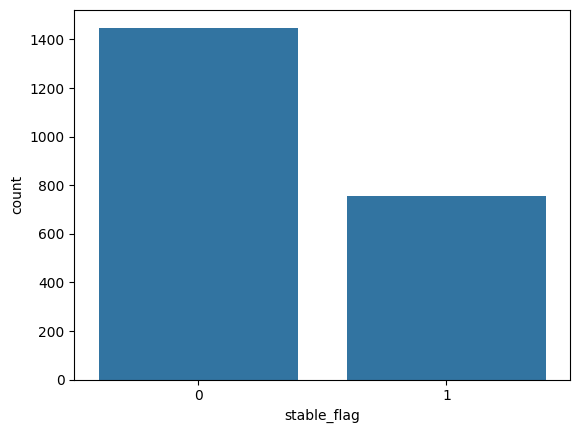

In [7]:
sns.countplot(
    data=df,
    x='stable_flag'
)

plt.show()

#4. MATRIZ DE CORRELACIÓN

In [8]:
corr_target = df.corr(numeric_only=True)['stable_flag']

corr_target.abs().sort_values(
    ascending=False
)

,stable_flag
stable_flag,1.000000
valve_condition,0.629433
pump_leakage,0.549678
SE_mean,0.324695
FS1_max,0.290922
...,...
CP_mean,0.003231
CP_max,0.002191
PS2_min,NaN
PS3_min,NaN


#5. SELECCIÓN DE VARIABLES

##5.1 Variables constantes

In [9]:
for col in df.columns:
    if df[col].nunique() == 1:
        print(col)

PS2_min
PS3_min
SE_min


##5.2 Eliminación de variables

In [10]:
cols_drop = [
    'cooler_condition',
    'valve_condition',
    'pump_leakage',
    'accumulator_pressure',
    'PS2_min',
    'PS3_min',
    'SE_min'
]

df_model = df.drop(
    columns=cols_drop
)

#6. DEFINICIÓN DE VARIABLES

In [11]:
X = df_model.drop(
    columns=['stable_flag']
)

y = df_model['stable_flag']

#7. DIVISIÓN DE DATOS

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

#8. ESTANDARIZACIÓN

In [13]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

#9. BALANCEO DE DATOS (SMOTE)

In [14]:
print(y_train.value_counts())

stable_flag
0    1014
1     529
Name: count, dtype: int64


In [15]:
smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

In [16]:
print(y_train_smote.value_counts())

stable_flag
0    1014
1    1014
Name: count, dtype: int64


#10. RANDOM FOREST

##10.1 Entrenamiento

In [17]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(
    X_train_smote,
    y_train_smote
)

RandomForestClassifier(random_state=42)

##10.2 Predicción

In [18]:
y_pred_rf = rf.predict(
    X_test_scaled
)

##10.3 Métricas

In [19]:
print(
    accuracy_score(
        y_test,
        y_pred_rf
    )
)

print(
    classification_report(
        y_test,
        y_pred_rf
    )
)

print(
    confusion_matrix(
        y_test,
        y_pred_rf
    )
)

0.9848942598187311
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       435
           1       1.00      0.96      0.98       227

    accuracy                           0.98       662
   macro avg       0.99      0.98      0.98       662
weighted avg       0.99      0.98      0.98       662

[[435   0]
 [ 10 217]]


##10.4 Validación cruzada

In [20]:
scores = cross_val_score(
    rf,
    X_train_smote,
    y_train_smote,
    cv=5,
    scoring='accuracy'
)

print(scores)
print(scores.mean())

[0.98029557 0.9729064  0.98275862 0.98518519 0.97283951]
0.9787970564982059


##10.5 AUC

In [21]:
auc_scores = cross_val_score(
    rf,
    X_train_smote,
    y_train_smote,
    cv=5,
    scoring='roc_auc'
)

print(auc_scores)
print(auc_scores.mean())

[0.99745201 0.9937999  0.99876241 0.99692728 0.99636639]
0.9966615963205193


##10.6 Importancia de variables

In [22]:
importance = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importancia',
    ascending=False
)

importance.head(10)

,Variable,Importancia
58,SE_mean,0.135515
38,FS1_mean,0.108150
39,FS1_std,0.084477
59,SE_std,0.074323
5,PS2_std,0.052376
18,PS6_mean,0.028965
0,PS1_mean,0.027606
16,PS5_max,0.024731
60,SE_max,0.023405
37,TS4_min,0.022700


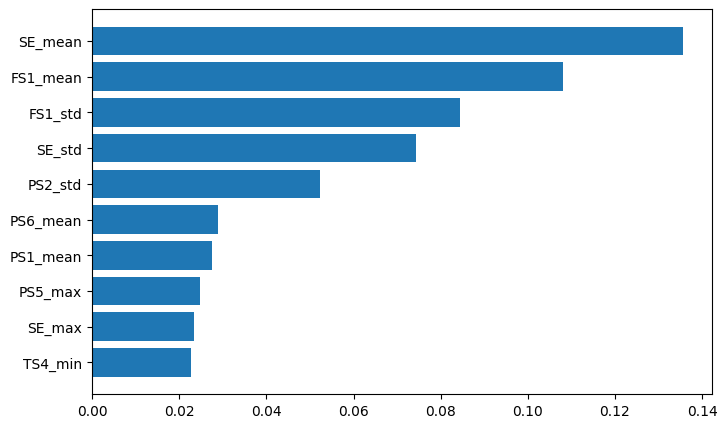

In [23]:
top10 = importance.head(10)

plt.figure(figsize=(8,5))

plt.barh(
    top10['Variable'],
    top10['Importancia']
)

plt.gca().invert_yaxis()

plt.show()

#11. KNN

##11.1 Entrenamiento

In [24]:
inicio = time.time()

knn = KNeighborsClassifier(
    n_neighbors=5
)

knn.fit(
    X_train_smote,
    y_train_smote
)

fin = time.time()

tiempo_knn = fin - inicio

##11.2 Predicción

In [25]:
y_pred_knn = knn.predict(
    X_test_scaled
)

##11.3 Métricas

In [26]:
print(
    accuracy_score(
        y_test,
        y_pred_knn
    )
)

print(
    classification_report(
        y_test,
        y_pred_knn
    )
)

print(
    confusion_matrix(
        y_test,
        y_pred_knn
    )
)

0.9607250755287009
              precision    recall  f1-score   support

           0       0.97      0.97      0.97       435
           1       0.94      0.94      0.94       227

    accuracy                           0.96       662
   macro avg       0.96      0.96      0.96       662
weighted avg       0.96      0.96      0.96       662

[[422  13]
 [ 13 214]]


##11.4 Búsqueda del mejor K

In [27]:
scores = []

for k in range(1,21):

    model = KNeighborsClassifier(
        n_neighbors=k
    )

    model.fit(
        X_train_smote,
        y_train_smote
    )

    pred = model.predict(
        X_test_scaled
    )

    scores.append(
        accuracy_score(
            y_test,
            pred
        )
    )

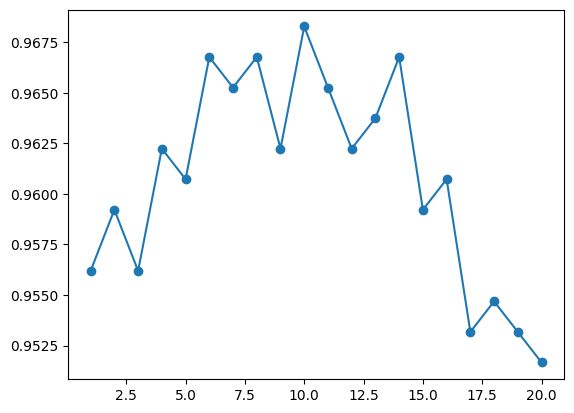

In [28]:
plt.plot(
    range(1,21),
    scores,
    marker='o'
)

plt.show()

#12. RED NEURONAL (MLP)



##12.1 Entrenamiento

In [29]:
inicio = time.time()

mlp = MLPClassifier(
    hidden_layer_sizes=(100,),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42
)

mlp.fit(
    X_train_smote,
    y_train_smote
)

fin = time.time()

tiempo_mlp = fin - inicio

##12.2 Predicción

In [30]:
y_pred_mlp = mlp.predict(
    X_test_scaled
)

##12.3 Métricas

In [31]:
print(
    accuracy_score(
        y_test,
        y_pred_mlp
    )
)

print(
    classification_report(
        y_test,
        y_pred_mlp
    )
)

print(
    confusion_matrix(
        y_test,
        y_pred_mlp
    )
)

0.9788519637462235
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       435
           1       0.97      0.96      0.97       227

    accuracy                           0.98       662
   macro avg       0.98      0.98      0.98       662
weighted avg       0.98      0.98      0.98       662

[[429   6]
 [  8 219]]


#13. COMPARACIÓN DE MODELOS

In [33]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
accuracy_knn = accuracy_score(y_test, y_pred_knn)
accuracy_mlp = accuracy_score(y_test, y_pred_mlp)

resultados = pd.DataFrame({
    'Modelo': [
        'Random Forest',
        'KNN',
        'MLP'
    ],
    'Accuracy': [
        accuracy_rf,
        accuracy_knn,
        accuracy_mlp
    ]
})

resultados

,Modelo,Accuracy
0,Random Forest,0.984894
1,KNN,0.960725
2,MLP,0.978852


#14. CLUSTERING (K-MEANS)

##14.1 Datos para clustering

In [35]:
X_cluster = df.drop(columns=[
    'stable_flag',
    'cooler_condition',
    'valve_condition',
    'pump_leakage',
    'accumulator_pressure',
    'PS2_min',
    'PS3_min',
    'SE_min'
])

##14.2 Escalado

In [36]:
from sklearn.preprocessing import StandardScaler

scaler_cluster = StandardScaler()

X_cluster_scaled = scaler_cluster.fit_transform(
    X_cluster
)

##14.3 Método del Codo
Ahora vamos a buscar el mejor número de clusters.

In [37]:
from sklearn.cluster import KMeans

inercia = []

for k in range(1,11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_cluster_scaled)

    inercia.append(
        kmeans.inertia_
    )

##14.4 Gráfica del Codo

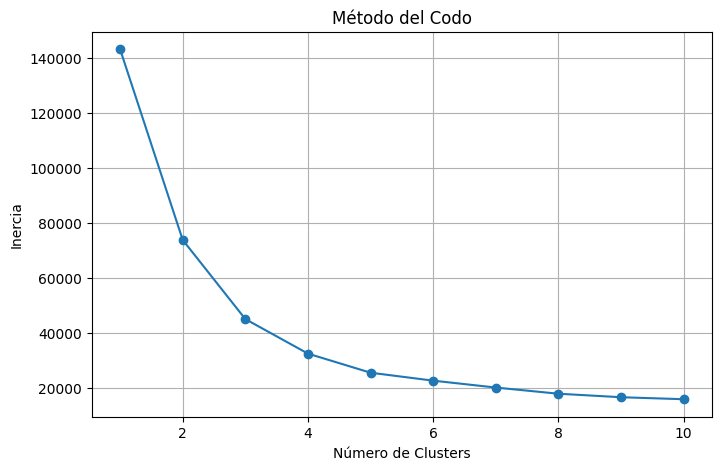

In [38]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    inercia,
    marker='o'
)

plt.xlabel('Número de Clusters')
plt.ylabel('Inercia')

plt.title('Método del Codo')

plt.grid(True)

plt.show()

##14.5 Silhouette Score
Ahora calculamos qué número de clusters funciona mejor.

In [39]:
from sklearn.metrics import silhouette_score

scores = []

for k in range(2,11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(
        X_cluster_scaled
    )

    score = silhouette_score(
        X_cluster_scaled,
        labels
    )

    scores.append(score)

    print(
        f"K={k}  ->  Silhouette={score:.4f}"
    )

K=2  ->  Silhouette=0.5122
K=3  ->  Silhouette=0.5748
K=4  ->  Silhouette=0.5729
K=5  ->  Silhouette=0.5761
K=6  ->  Silhouette=0.5835
K=7  ->  Silhouette=0.5396
K=8  ->  Silhouette=0.5410
K=9  ->  Silhouette=0.5006
K=10  ->  Silhouette=0.5081


##14.6 Gráfica Silhouette

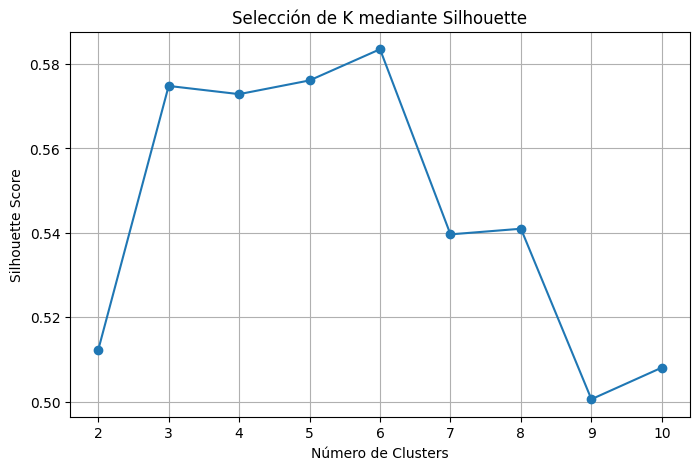

In [40]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    scores,
    marker='o'
)

plt.xlabel("Número de Clusters")
plt.ylabel("Silhouette Score")

plt.title("Selección de K mediante Silhouette")

plt.grid(True)

plt.show()

##14.7 PCA para visualización

In [41]:
from sklearn.decomposition import PCA

pca = PCA(
    n_components=2,
    random_state=42
)

X_pca = pca.fit_transform(
    X_cluster_scaled
)

print(
    pca.explained_variance_ratio_
)

[0.6221569  0.14456893]


##14.8 K-Means Final

In [52]:
kmeans_final = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clusters = kmeans_final.fit_predict(
    X_cluster_scaled
)

##14.9 Visualización de Clusters

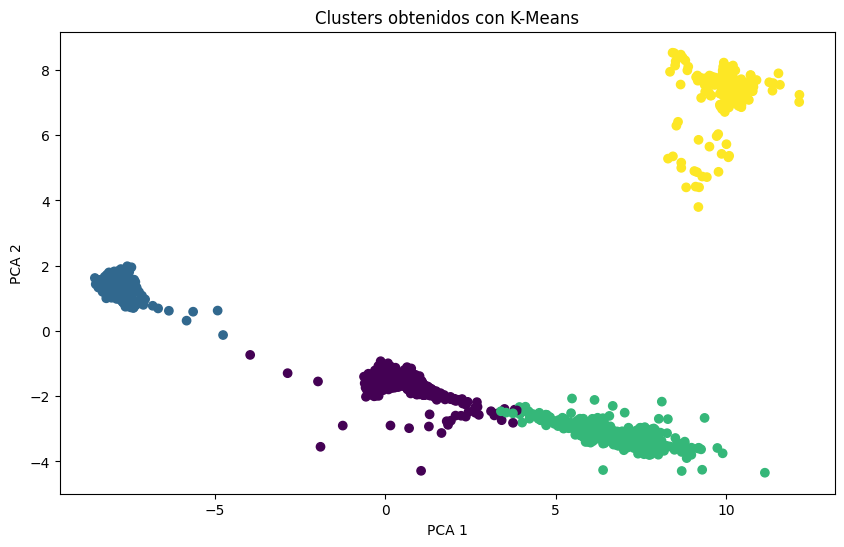

In [53]:
plt.figure(figsize=(10,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=clusters
)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")

plt.title("Clusters obtenidos con K-Means")

plt.show()

In [54]:
pd.Series(clusters).value_counts()

,count
0,753
1,737
2,475
3,240


In [55]:
centroides_original = pd.DataFrame(
    scaler_cluster.inverse_transform(
        kmeans_final.cluster_centers_
    ),
    columns=X_cluster.columns
)

centroides_original

,PS1_mean,PS1_std,PS1_max,PS1_min,PS2_mean,PS2_std,PS2_max,PS3_mean,PS3_std,PS3_max,...,CE_std,CE_max,CE_min,SE_mean,SE_std,SE_max,CP_mean,CP_std,CP_max,CP_min
0,158.524430,14.737914,190.930837,143.341262,107.373543,46.489713,166.512696,1.771948,0.873350,10.690296,...,0.302088,27.663436,26.536271,58.379164,23.580461,78.433483,1.729550,0.023398,1.777757,1.690437
1,160.828212,14.101723,191.566974,146.132185,109.252654,47.256603,167.238562,1.968166,0.931326,9.657239,...,0.280655,47.546172,46.457434,57.652059,23.264325,76.823856,2.162758,0.020525,2.208430,2.129300
2,156.734833,15.127757,190.357200,141.048758,105.884477,45.817197,165.821032,1.718397,0.864756,11.009400,...,0.290340,20.371008,19.265653,59.394225,23.921513,80.375171,1.531920,0.024796,1.580728,1.485343
3,173.007438,21.049414,189.872500,140.517167,122.983678,56.917492,165.724458,1.103387,0.951074,10.657479,...,0.255524,19.782350,18.792771,30.202015,29.137349,93.249325,1.514804,0.022966,1.561908,1.471321


In [57]:
df_cluster = df.copy()
df_cluster['cluster'] = clusters

##14.10 Interpretacion clusters con variables objetivo

In [58]:
objetivos = [
    'stable_flag',
    'cooler_condition',
    'valve_condition',
    'pump_leakage',
    'accumulator_pressure'
]

for var in objetivos:
    print(f"\n{'='*40}")
    print(var)

    print(
        pd.crosstab(
            df_cluster['cluster'],
            df_cluster[var],
            normalize='index'
        )*100
    )


stable_flag
stable_flag          0          1
cluster                          
0            63.745020  36.254980
1            66.350068  33.649932
2            52.000000  48.000000
3            97.083333   2.916667

cooler_condition
cooler_condition         3          20          100
cluster                                            
0                   3.054449  96.414343    0.531208
1                   0.000000   0.000000  100.000000
2                  98.736842   1.263158    0.000000
3                 100.000000   0.000000    0.000000

valve_condition
valve_condition        73         80         90         100
cluster                                                    
0                15.936255  15.936255  15.936255  52.191235
1                16.282225  16.282225  16.282225  51.153324
2                13.052632  13.263158  13.052632  60.631579
3                24.166667  23.750000  24.166667  27.916667

pump_leakage
pump_leakage          0          1          2
cluster         

#15.Despliegue

In [ ]:
# =====================================
# LIBRERÍAS
# =====================================

import joblib
import pandas as pd

# =====================================
# 1. GUARDAR MODELO RANDOM FOREST
# =====================================

joblib.dump(
    rf,
    "random_forest.pkl"
)

print("✓ random_forest.pkl generado")

# =====================================
# 2. GUARDAR SCALER
# =====================================

joblib.dump(
    scaler,
    "scaler.pkl"
)

print("✓ scaler.pkl generado")

# =====================================
# 3. GUARDAR NOMBRES DE COLUMNAS
# =====================================

joblib.dump(
    list(X.columns),
    "columnas.pkl"
)

print("✓ columnas.pkl generado")

# =====================================
# 4. GUARDAR MEDIAS DE LAS VARIABLES
# =====================================

medias = X.mean()

joblib.dump(
    medias,
    "medias.pkl"
)

print("✓ medias.pkl generado")

# =====================================
# 5. IMPORTANCIA DE VARIABLES
# =====================================

importance = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importancia",
    ascending=False
)

importance.to_csv(
    "feature_importance.csv",
    index=False
)

print("✓ feature_importance.csv generado")

# =====================================
# 6. CREAR CSV DE EJEMPLO
# =====================================

ejemplo = X.head(5)

ejemplo.to_csv(
    "ejemplo_entrada.csv",
    index=False
)

print("✓ ejemplo_entrada.csv generado")

# =====================================
# RESUMEN
# =====================================

print("\nArchivos creados:")
print("- random_forest.pkl")
print("- scaler.pkl")
print("- columnas.pkl")
print("- medias.pkl")
print("- feature_importance.csv")
print("- ejemplo_entrada.csv")

In [ ]:
from google.colab import files

archivos = [
    "random_forest.pkl",
    "scaler.pkl",
    "columnas.pkl",
    "medias.pkl",
    "feature_importance.csv",
    "ejemplo_entrada.csv"
]

for archivo in archivos:
    files.download(archivo)